Đang khởi chạy thuật toán Bán giám sát Self-Training...
--------------------------------------------------


Tỷ lệ nhãn 10% | Chỉ dùng Supervised F1: 0.5890 | Semi-supervised F1: 0.4347
Tỷ lệ nhãn 20% | Chỉ dùng Supervised F1: 0.7328 | Semi-supervised F1: 0.5310
Tỷ lệ nhãn 30% | Chỉ dùng Supervised F1: 0.7550 | Semi-supervised F1: 0.6451


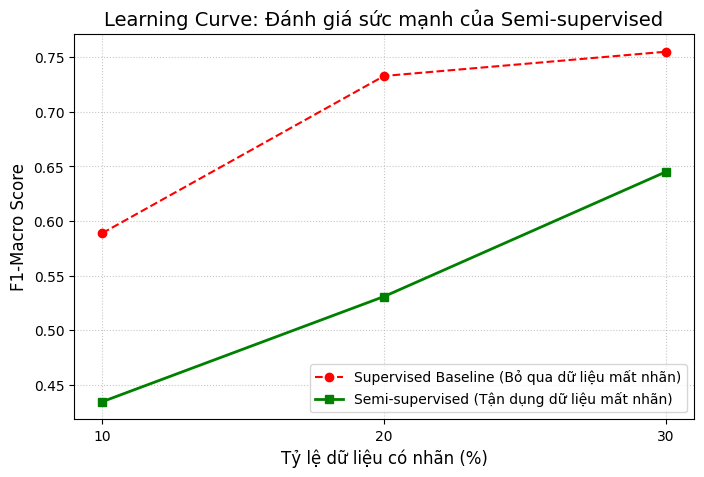

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.append(os.getcwd())

from src.models.semi_supervised import evaluate_semi_supervised

# 1. Chuẩn bị dữ liệu
df = pd.read_csv("data/processed/featured_reviews.csv")
df = df.dropna(subset=['reviews.rating', 'Cleaned_Review']).copy()
df['Sentiment'] = df['reviews.rating'].apply(lambda x: 1 if float(x) >= 4 else 0)

# 2. Chạy hàm đánh giá với kịch bản giữ lại 10%, 20% và 30% nhãn
print("Đang khởi chạy thuật toán Bán giám sát Self-Training...\n" + "-"*50)
results_df = evaluate_semi_supervised(df, label_rates=[0.1, 0.2, 0.3])

# 3. Vẽ biểu đồ Learning Curve
plt.figure(figsize=(8, 5))
plt.plot(results_df['Label_Ratio'] * 100, results_df['Supervised_F1'], 
         marker='o', label='Supervised Baseline (Bỏ qua dữ liệu mất nhãn)', linestyle='--', color='red')
plt.plot(results_df['Label_Ratio'] * 100, results_df['SemiSupervised_F1'], 
         marker='s', label='Semi-supervised (Tận dụng dữ liệu mất nhãn)', linewidth=2, color='green')

plt.title('Learning Curve: Đánh giá sức mạnh của Semi-supervised', fontsize=14)
plt.xlabel('Tỷ lệ dữ liệu có nhãn (%)', fontsize=12)
plt.ylabel('F1-Macro Score', fontsize=12)
plt.xticks([10, 20, 30])
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()